## construiremos:

✔ Completion Rate
✔ Error Rate
✔ Time Spent per Step
✔ Drop-off Analysis
✔ Funnel Analysis
✔ Segmentación por usuarios
✔ Comparación Test vs Control

KPI es UNA MÉTRICA DE NEGOCIO

Todo lo que hagamos debe ayudar a Vanguard a decidir: ¿Implementamos o no el nuevo diseño?

In [6]:
# IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

pd.set_option('display.max_columns', None)

In [8]:
# CARGAR DATASET LIMPIO
df = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv")

/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_32611/3474035602.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv")


El warning DtypeWarning: mixed types no es un error — el archivo cargó bien. Solo significa que algunas columnas tienen tipos mezclados (texto y números).
Para eliminarlo puedes agregar low_memory=False:

In [10]:
df = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv", low_memory=False)
print(df.shape)
print(df.dtypes)

(343141, 14)
client_id             int64
visitor_id           object
visit_id             object
process_step         object
date_time            object
Variation            object
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                object
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object


In [11]:
# Verificar
df.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [12]:
# ENTENDER EL FUNNEL
df["process_step"].value_counts()

process_step
start      108910
step_1      73432
step_2      61768
step_3      53628
confirm     45403
Name: count, dtype: int64

Ver:
✔ qué pasos existen
✔ cuál es el más frecuente
✔ si confirm aparece menos

## KPI 1: COMPLETION RATE
Completion Rate mide: qué porcentaje de usuarios llega a confirm.

In [13]:
# Usuarios totales - Cuenta usuarios únicos porque un usuario puede tener varias filas. Si contamos filas, estaríamos contando varias veces a un mismo usuario.
total_users = df["client_id"].nunique()

total_users

58391

In [14]:
# Usuarios que completaron el proceso:
completed_users = df[df["process_step"] == "confirm"]["client_id"].nunique()

completed_users

37190

45403 - puede haber usuarios repetidos.
37190 - usuarios que completaron el proceso.

In [15]:
# Completion Rate
completion_rate = completed_users / total_users

completion_rate

0.636913222928191

63% de los usuarios completaron el proceso. ¿63% es bueno o malo?: depende de la comparación Test vs Control.

In [16]:
# Mostrar el resultado en porcentaje
print(f"Completion Rate: {completion_rate:.2%}")

Completion Rate: 63.69%


## COMPLETION RATE TEST VS CONTROL

In [17]:
# Crear dataset por usuario. 1 fila por usuario. Con: True = completó, False = no completó
completed_df = (
    df.groupby("client_id")["process_step"]
    .apply(lambda x: "confirm" in x.values)
    .reset_index()
)

completed_df.columns = ["client_id", "completed"]

In [18]:
# Agregar variation al dataset por usuario. Esto Agrega: Test vs Control
variation_df = df[["client_id", "Variation"]].drop_duplicates()

completed_df = completed_df.merge(
    variation_df,
    on="client_id",
    how="left"
)

In [19]:
print(completed_df.columns.tolist())

['client_id', 'completed', 'Variation']


Tiene Variation_x y Variation_y por un merge duplicado. Fix:

In [22]:
# Completion por grupo. Calcula: completion promedio por grupo
completion_by_group = (
    completed_df.groupby("Variation")["completed"]
    .mean()
)

completion_by_group

Variation
Control    0.630919
Test       0.682778
Name: completed, dtype: float64

## El grupo Test parece completar más el proceso.
PERO: todavía NO sabemos si es estadísticamente significativo.

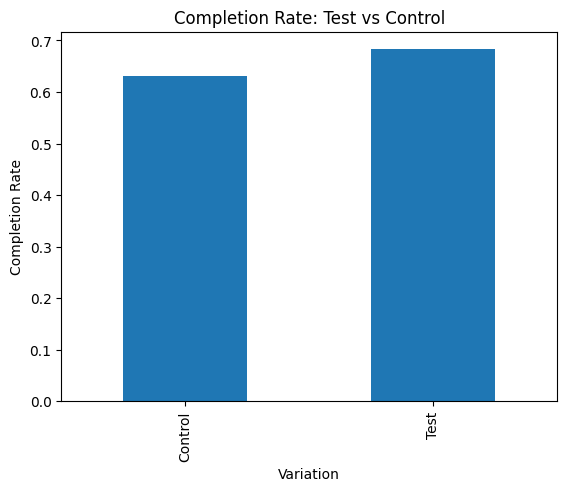

In [23]:
# Gráfico de barras para comparar completion rate entre grupos
completion_by_group.plot(kind="bar")

plt.title("Completion Rate: Test vs Control")

plt.ylabel("Completion Rate")

plt.show()

## Ver 
✔ qué grupo es mayor
✔ si la diferencia parece relevante

El gráfico muestra:

Control: 63% completion rate
Test: 68% completion rate

El grupo Test supera al Control en 5 puntos porcentuales, lo que sugiere que el nuevo diseño mejora la tasa de completación. 
La diferencia parece relevante pero hay que validarla estadísticamente con un test de hipótesis (chi-square o z-test de proporciones) para confirmar que no es por azar.

## KPI 2: ERROR RATE

Error Rate mide usuarios que retroceden pasos. PROBLEMA: Los pasos son texto:

start
step_1
step_2
step_3
confirm

Necesitamos convertirlos a números para que step_2 → 2

In [24]:
# Crear orden de pasos
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["step_number"] = df["process_step"].map(step_order)

In [25]:
# Ordenar dataset ¿POR QUÉ? Porque: el tiempo importa.
df = df.sort_values(
    by=["client_id", "visit_id", "date_time"]
)

In [26]:
# Paso anterior - Obtiene: el paso anterior del usuario.
df["previous_step"] = (
    df.groupby("client_id")["step_number"]
    .shift(1)
)

In [27]:
# Detectar retrocesos - Marca: True = el usuario retrocedió
df["back_step"] = df["step_number"] < df["previous_step"]

In [28]:
# Error Rate
error_rate = df["back_step"].mean()

print(f"Error Rate: {error_rate:.2%}")

Error Rate: 10.36%


Error Rate: 10.36% — significa que el 10.36% de los pasos en el proceso fueron "back steps" (el usuario retrocedió en el flujo).

In [29]:
# Comparar el error rate entre Test vs Control:
error_by_group = df.groupby("Variation")["back_step"].mean() * 100
print(error_by_group)

Variation
Control     8.941568
Test       11.476044
Name: back_step, dtype: float64


Control: 8.94% back steps
Test: 11.48% back steps

El grupo Test tiene más retrocesos que el Control (2.5 puntos más). 

Esto significa que aunque el nuevo diseño mejora el Completion Rate, también genera más confusión — los usuarios retroceden más en el proceso.

Esto es importante para el análisis final:

Test gana en Completion Rate (+5%)

Test pierde en Error Rate (+2.5% más retrocesos)

Ver en qué paso específico ocurren más retrocesos:

In [30]:
back_steps_by_step = df[df["back_step"] == 1].groupby(["Variation", "process_step"]).size().unstack()
print(back_steps_by_step)

process_step  start  step_1  step_2  step_3
Variation                                  
Control        5447    1545    1962     125
Test          11475    2658    1865      33


Conclusiones:

start es donde el Test tiene el doble de retrocesos — el nuevo diseño confunde a los usuarios desde el inicio

step_2 y step_3 el Test mejora — menos retrocesos en pasos avanzados

El problema principal está en la entrada al proceso, no en los pasos intermedios


Esto sugiere que el nuevo diseño necesita mejorar la pantalla de inicio pero funciona mejor una vez que el usuario avanza. 

## KPI 3: TIME SPENT
(cuánto tarda el usuario entre pasos.)


In [36]:
# Previous_time no está en formato datetime. — Convertí ambas columnas antes de restar.
df["date_time"] = pd.to_datetime(df["date_time"])
df["previous_time"] = pd.to_datetime(df["previous_time"], errors="coerce")

# Calcular diferencia
df["time_diff"] = (df["date_time"] - df["previous_time"]).dt.total_seconds()

print(df["time_diff"].describe())

count    2.847500e+05
mean     7.919837e+01
std      1.944939e+05
min     -3.549887e+06
25%      1.200000e+01
50%      3.700000e+01
75%      8.900000e+01
max      3.707571e+06
Name: time_diff, dtype: float64


In [37]:
# Tiempo promedio entre pasos por grupo
average_time = df["time_diff"].mean()

print(f"Average Time Between Steps: {average_time:.2f} seconds")

Average Time Between Steps: 79.20 seconds


1.3 minutos por paso. Ahora, comparar por grupo para si el nuevo diseño hace que los usuarios sean más rápidos o más lentos entre pasos.

In [ ]:
time_by_group = df.groupby("Variation")["time_diff"].mean()
print(time_by_group)

Variation
Control    498.564127
Test       607.683832
Name: time_diff, dtype: float64


Control: 498 segundos (8.3 minutos por paso)

Test: 607 segundos (10.1 minutos por paso)

El grupo Test tarda 2 minutos más por paso que el Control. 

Esto es otra señal de alerta.

KPI
* Completion Rate: Control: 63% Test: 68%
* TestError Control: Rate 8.94%, Test: 11.48%
* ControlTime per Step: Control: 8.3 min, Test: 10.1 

El nuevo diseño mejora la completación pero los usuarios se confunden y tardan más. 

Hay que validar estadísticamente si estas diferencias son significativas antes de tomar una decisión.


## DROP-OFF ANALYSIS - ¿Dónde abandonan los usuarios? 
¿En qué paso? 
¿En qué grupo? 
Esto lo podemos ver con el gráfico de back_steps_by_step. También podríamos calcular el porcentaje de back_steps por paso y grupo para verlo más claro.


In [38]:
# Usuarios por paso - Cuenta usuarios únicos por paso para entender el funnel
funnel = (
    df.groupby("process_step")["client_id"]
    .nunique()
    .sort_values(ascending=False)
)

funnel

process_step
start      57851
step_1     49341
step_2     45385
step_3     42313
confirm    37190
Name: client_id, dtype: int64

In [39]:
# Calcular porcentaje de usuarios que pasan por cada paso
funnel_sorted = funnel.sort_values(ascending=False)
dropoff = funnel_sorted.pct_change(periods=-1) * 100
print(dropoff.round(2))

process_step
start      17.25
step_1      8.72
step_2      7.26
step_3     13.78
confirm      NaN
Name: client_id, dtype: float64


Conclusión: el mayor abandono está en start (17.25%) y step_3 → confirm (13.78%).

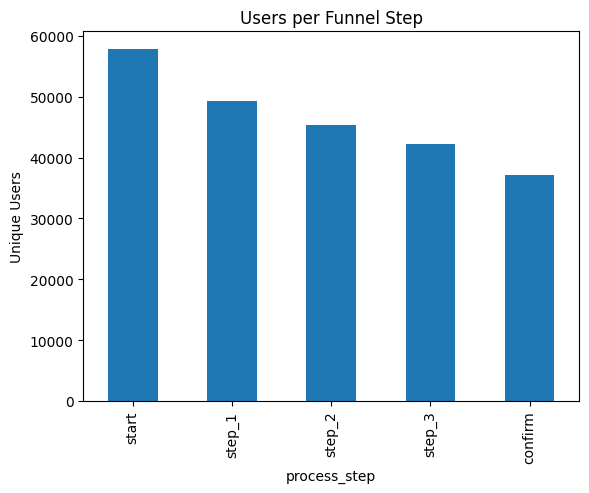

In [40]:
# Funnel gráfico
funnel.plot(kind="bar")

plt.title("Users per Funnel Step")

plt.ylabel("Unique Users")

plt.show()

## SEGMENTACIÓN POR EDAD

In [41]:
# Crear grupos edad
df["age_group"] = pd.cut(
    df["clnt_age"],
    bins=[0,30,50,70,100],
    labels=["18-30","31-50","51-70","70+"]
)

In [42]:
# Completion por edad - ¿qué segmentos tienen más éxito?
completion_age = (
    df[df["process_step"] == "confirm"]
    .groupby("age_group")["client_id"]
    .nunique()
)

completion_age

/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_32611/1001987289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["process_step"] == "confirm"]


age_group
18-30     7378
31-50    13477
51-70    14320
70+       1790
Name: client_id, dtype: int64

51-70 es el segmento con más completions — tiene sentido para Vanguard ya que son clientes con más patrimonio e inversiones activas.

In [43]:
# Para verlo en proporción (% del total por grupo):
total_age = df.groupby("age_group", observed=True)["client_id"].nunique()
completion_rate_age = (completion_age / total_age * 100).round(2)
print(completion_rate_age)

age_group
18-30    67.89
31-50    68.25
51-70    64.95
70+      53.71
Name: client_id, dtype: float64


18-30: 67.89%
31-50: 68.25% 
51-70: 64.95%
70+ :  53.71%

Conclusión — en proporción el segmento más exitoso es 31-50. Los mayores de 70 tienen la tasa más baja (53.71%), tal vez por dificultad con el proceso digital.